In [85]:
# Install datasets Library (if not already installed)
# !pip install -U datasets

# Importing Libraries
import seaborn as sns
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  # we will use this for plotting

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [86]:
df_US = df[df['job_country'] == 'United States'].dropna(subset= 'salary_year_avg').copy()
df_skills = df_US.explode('job_skills')
job_titles = ['Data Analyst', 'Business Analyst', 'Data Engineer']
df_skills[['job_title_short', 'job_skills']]
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name= 'skill_count')
total_count = df_US['job_title_short'].value_counts().reset_index(name= 'total')

df_skills_count= df_skills_count.merge(total_count, on= 'job_title_short')
df_skills_count['perc'] = (df_skills_count['skill_count']/df_skills_count['total'])*100
df_skills_count


,job_skills,job_title_short,skill_count,total,perc
0,airflow,Business Analyst,3,431,0.696056
1,airflow,Cloud Engineer,5,20,25.000000
2,airflow,Data Analyst,44,4350,1.011494
3,airflow,Data Engineer,458,2915,15.711835
4,airflow,Data Scientist,94,4553,2.064573
...,...,...,...,...,...
1285,zoom,Data Engineer,6,2915,0.205832
1286,zoom,Data Scientist,15,4553,0.329453
1287,zoom,Senior Data Analyst,9,913,0.985761
1288,zoom,Senior Data Engineer,4,1058,0.378072


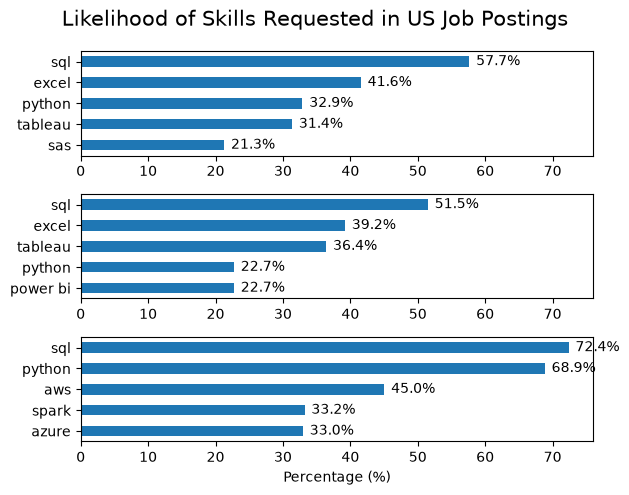

In [87]:
fig, ax= plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    data = df_skills_count[df_skills_count['job_title_short'] == job_title].sort_values(by='skill_count', ascending=False).head()
    data.plot(kind='barh', ax=ax[i], x='job_skills', y='perc', legend='')
    ax[i].yaxis.set_inverted(True)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 76)

    for j, n in enumerate(data['perc']):
        ax[i].text(x=n+1, y=j, s=f'{n:.1f}%', va= 'center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize= 15)
fig.tight_layout()
ax[-1].set_xlabel('Percentage (%)')
plt.show()


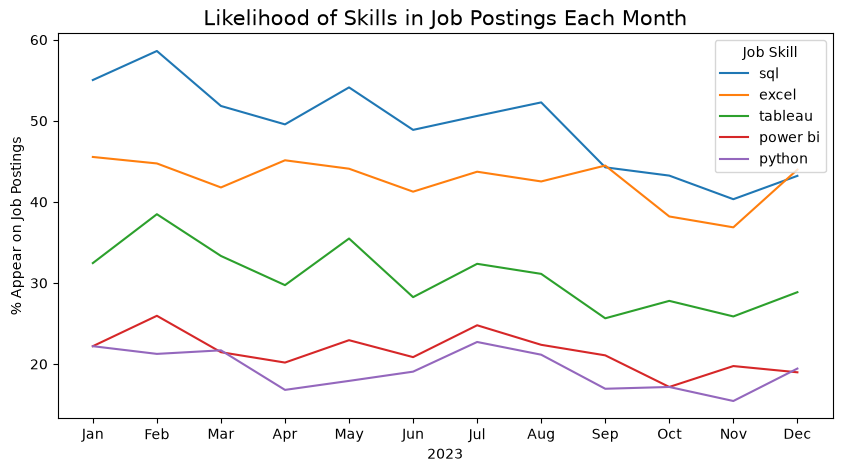

In [181]:
import calendar

df_BA_US = df[(df['job_title_short'] == 'Business Analyst') & (df['job_country'] == 'United States')].copy()

df_BA_US['job_month'] = df_BA_US['job_posted_date'].dt.month
df_BA_US_exploded = df_BA_US.explode('job_skills')
skills = df_BA_US_exploded['job_skills'].dropna().unique()

df_BA_US_pivot = df_BA_US_exploded.pivot_table(index= 'job_month', columns= 'job_skills', aggfunc= 'size', fill_value= 0).astype(float)
df_BA_US_pivot.loc['Total'] = df_BA_US_pivot.sum()


months = [m for m in df_BA_US_pivot.index if m != 'Total']
for skill in skills:
    for month in months:
        df_BA_US_pivot.loc[month, skill] = df_BA_US_pivot.loc[month, skill]*100/df_BA_US.groupby('job_month').size()[month]
        df_BA_US_pivot.loc[month, skill] = df_BA_US_pivot.loc[month, skill].round(2)
top_skills = df_BA_US_pivot.loc['Total'].sort_values(ascending= False).head().index.to_list()

df_BA_US_pivot.index = df_BA_US_pivot.index.map(
    lambda m: calendar.month_abbr[int(m)] if m != 'Total' else m
)
df_BA_US_plot = df_BA_US_pivot.drop('Total')
df_BA_US_plot[top_skills].plot(kind= 'line', figsize= (10, 5))

ax = plt.gca()
ax.set_xticks(range(len(df_BA_US_plot.index)))
ax.set_xticklabels(df_BA_US_plot.index, rotation=0)
ax.set_xlabel('2023')
ax.set_ylabel('% Appear on Job Postings')
plt.title('Likelihood of Skills in Job Postings Each Month', fontsize= 15)
plt.legend().set_title('Job Skill')
plt.show()

C:\Users\AD\AppData\Local\Temp\ipykernel_13356\1125842960.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_US_top3, tick_labels= job_titles, vert= False)


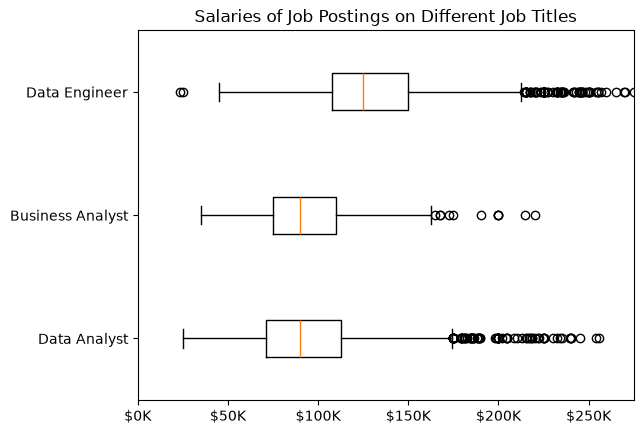

In [174]:
df_US
df_US_top3 = [df_US[df_US['job_title_short'] == job]['salary_year_avg'] for job in job_titles]

plt.boxplot(df_US_top3, tick_labels= job_titles, vert= False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.title('Salaries of Job Postings on Different Job Titles')
plt.xlim(0, 275000)
plt.tight_layout
plt.show()

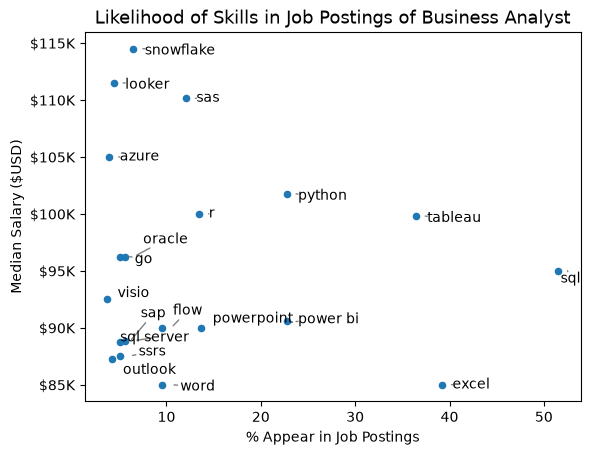

In [172]:
from adjustText import adjust_text
df_BA_US_scatter = df_BA_US_exploded[df_BA_US_exploded['salary_year_avg'].notna()].groupby('job_skills')['salary_year_avg'].agg(['size','median']).sort_values(by= 'size', ascending= False)
df_BA_US_scatter = df_BA_US_scatter.rename(columns= {'size': 'skill_count', 'median': 'median_salary'})

df_BA_US_scatter['percentage'] = (df_BA_US_scatter['skill_count'] / len(df_BA_US.dropna(subset= 'salary_year_avg')))*100
df_BA_US_scatter.head(20).plot(kind= 'scatter', x= 'percentage', y= 'median_salary')

texts =[]
for i, n in enumerate(df_BA_US_scatter.head(20).index.tolist()):
    texts.append(plt.text(df_BA_US_scatter.reset_index().loc()[i, 'percentage'] + 1, df_BA_US_scatter.reset_index().loc[i, 'median_salary'], n, va= 'center'))
adjust_text(texts, arrowprops= dict(arrowstyle= '-', color= 'gray', lw= '1'))


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.title('Likelihood of Skills in Job Postings of Business Analyst', fontsize= 13)
plt.xlabel('% Appear in Job Postings')
plt.ylabel('Median Salary ($USD)')
plt.tight_layout
plt.show()
